# Section 1: Introduction to Generative Models

> Based on *"Understanding Diffusion Models: A Unified Perspective"* by Calvin Luo (2022)

## What is a Generative Model?

Given observed data samples **x** drawn from some unknown distribution **p(x)**, the goal of a generative model is to **learn an approximation of p(x)**.

Once learned, we can:
- **Sample** new data points that look like real data
- **Evaluate** the likelihood of any given data point

This notebook builds intuition for the problem, surveys the main families of generative models, and positions **diffusion models** as the approach we will study in depth.

## The Core Problem

Imagine you have a dataset of images of cats. You don't know the mathematical formula that describes "cat-ness" you only have examples.

A generative model looks at those examples and tries to learn the underlying distribution **p(x)** well enough to:
1. Generate a new image that looks like a cat (sampling)
2. Tell you whether a given image is likely to be a cat (likelihood)

The same idea applies to any kind of data: images, audio, text, molecules, etc.

40 percent chance of '0' and 60 percent for '1'  [0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 0 0 1 1 1 0
 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1
 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1
 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 0
 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1 1 0 1 0 0 1 1 1 1 1
 0 0 0 0 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1
 0 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0 0 1
 1 0 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 1 0 0 1 0
 0 0 0 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1 1 1 0 1 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 0
 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 0 0 1 1 1 1 0 0 1 0 

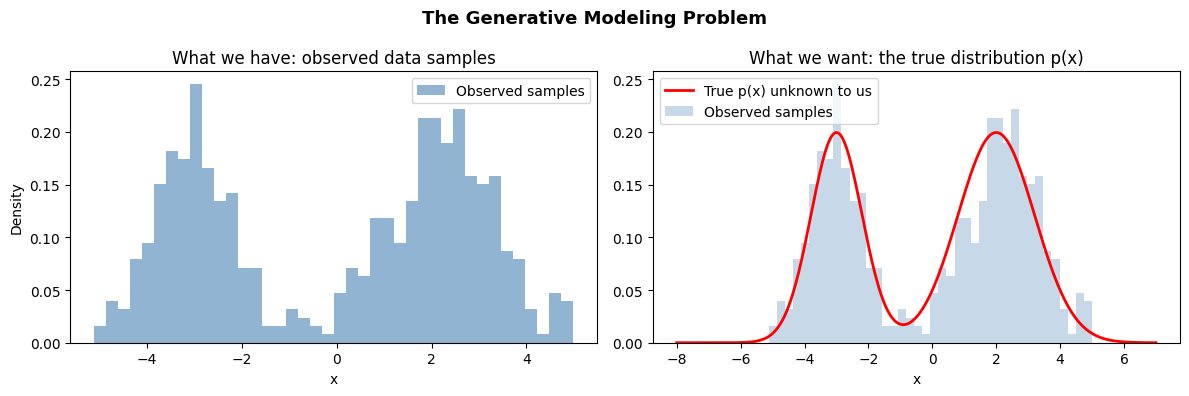

Dataset size: 500 samples
We only see the histogram (left). The goal is to recover something like the curve (right).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

# Simulate a "true" distribution: mixture of two Gaussians
def sample_true_distribution(n):
    component = np.random.choice([0, 1], size=n, p=[0.4, 0.6])
    
    print("40 percent chance of '0' and 60 percent for '1' ",component)
    
    samples = np.where(
        component == 0,
        np.random.normal(-3, 0.8, n),
        np.random.normal(2, 1.2, n)
    )
    print(samples.size)
    return samples


observed_data = sample_true_distribution(500)

# Plot: what we have (samples) vs what we want (the true distribution)
x_range = np.linspace(-8, 7, 300)
true_density = 0.4 * (1/(0.8*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range+3)/0.8)**2) + \
               0.6 * (1/(1.2*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range-2)/1.2)**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(observed_data, bins=40, density=True, alpha=0.6, color='steelblue', label='Observed samples')
axes[0].set_title("What we have: observed data samples")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].plot(x_range, true_density, 'r-', linewidth=2, label='True p(x) unknown to us')
axes[1].hist(observed_data, bins=40, density=True, alpha=0.3, color='steelblue', label='Observed samples')
axes[1].set_title("What we want: the true distribution p(x)")
axes[1].set_xlabel("x")
axes[1].legend()

plt.suptitle("The Generative Modeling Problem", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Dataset size: {len(observed_data)} samples")
print("We only see the histogram (left). The goal is to recover something like the curve (right).")

## The 5 Families of Generative Models

The paper surveys the major approaches. Here's a high-level map:

| Family | Core Idea | Gives Likelihoods? | Training Stability |
|---|---|---|---|
| **GANs** | Train generator vs. discriminator adversarially | No (implicit) | Tricky (mode collapse) |
| **Autoregressive** | Model p(x) = p(x₁) · p(x₂\|x₁) · p(x₃\|x₁,x₂) ... | Yes (exact) | Stable, but slow sampling |
| **Normalizing Flows** | Learn invertible transforms from data → Gaussian | Yes (exact) | Stable, architecture constraints |
| **VAEs** | Encode to latent z, decode back; maximize ELBO | Yes (lower bound) | Stable, blurry samples |
| **Diffusion Models** | Gradually add/remove noise; learn to reverse | Yes (lower bound) | Stable, high quality |

> **Diffusion models** sit at the intersection of likelihood-based and score-based modeling that's the unique perspective this paper (and repo) unpacks.

## Why Diffusion Models?

The paper's key insight, stated right in the Introduction:

> *"Diffusion models have both likelihood-based and score-based interpretations."*

This means they:
- Can assign likelihoods to data (like VAEs, flows, autoregressive models)
- Connect to score matching / energy-based modeling (a separate, powerful tradition)
- Achieve **state-of-the-art sample quality** with **stable training** (no adversarial game)

### The Road Ahead

To understand diffusion models deeply, the paper (and this repo) builds up from first principles:

```
ELBO  →  VAE  →  Hierarchical VAE  →  Variational Diffusion Models
                                              ↓
                                   Three Equivalent Interpretations
                                              ↓
                                    Score-based Models  +  Guidance
```

**Next section:** `02_elbo_vae` we'll derive the Evidence Lower Bound and implement a VAE from scratch.